# Imports

In [1]:
import json
import os
import random
import re
import time
from collections import Counter
from datetime import datetime
from itertools import islice
from pathlib import Path
from typing import Any

import lyricsgenius
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from IPython.display import clear_output
from dotenv import load_dotenv
from nltk.corpus import stopwords
from openai import OpenAI
from tqdm.notebook import tqdm

In [2]:
random.seed(42)

RAW_HITS_PATH = Path("../data/raw/genius_tag_hits.json")
HARVESTED_PATH = Path("../data/raw/genius_harvested_corpus.json")
CLEANED_PHRASES_PATH = Path("../data/processed/genius_cleaned_phrases.json")
PROGRESS_PATH = Path("../data/processed/grading_progress.json")
GOLD_BENCHMARK_PATH = Path("../data/processed/gold_benchmark_150.json")

TAGS = ["israeli-hip-hop", "israeli-rap", "israeli-drill", "israeli-trap"]


def get_genius_client() -> lyricsgenius.Genius:
    """Initializes and returns an authenticated Genius API client."""
    load_dotenv()
    token = os.getenv("GENIUS_ACCESS_TOKEN")
    if not token:
        raise ValueError("GENIUS_ACCESS_TOKEN not set in environment.")
    
    genius = lyricsgenius.Genius(token, timeout=15, retries=3, sleep_time=0.5)
    genius.verbose = False
    return genius

## Step 1: Harvesting Raw Song Metadata via Genius Tag API

In [3]:
def fetch_and_save_raw_hits(
    tags: list[str], 
    path: Path, 
    max_pages: int = 50
) -> dict[str, dict[str, Any]]:
    """Fetches song metadata by tags, tracks tag associations, and caches to disk.

    Args:
        tags: List of Genius genre tag slugs.
        path: Filepath to load from or save to.
        max_pages: Maximum tag pages to query (20 hits per page).

    Returns:
        Dictionary of raw song hits mapped by song URL.
    """
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            hits = json.load(f)
        print(f"Loaded {len(hits)} songs from cache: {path}")

        tag_counts = Counter(
            tag for hit in hits.values() for tag in hit.get("found_in_tags", [])
        )
        print("\nPer-tag breakdown (cached):")
        for tag in tags:
            print(f"  {tag}: {tag_counts.get(tag, 0)} hits")
        return hits

    genius = get_genius_client()
    hits: dict[str, dict[str, Any]] = {}

    for tag in tags:
        # Wrap the range in tqdm to show a progress bar for each tag
        for page in tqdm(range(1, max_pages + 1), desc=f"Fetching {tag}"):
            try:
                res = genius.tag(tag, page=page)
                page_hits = res.get("hits", [])
                
                if not page_hits:
                    break

                for hit in page_hits:
                    url = hit.get("url")
                    if not url:
                        continue
                        
                    entry = hits.setdefault(url, hit)
                    entry.setdefault("found_in_tags", [])
                    if tag not in entry["found_in_tags"]:
                        entry["found_in_tags"].append(tag)

            except Exception as e:
                print(f"Error fetching {tag} page {page}: {e}")
                break

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(hits, f, ensure_ascii=False, indent=2)

    tag_counts = Counter(
        tag for hit in hits.values() for tag in hit.get("found_in_tags", [])
    )
    print(f"\nSaved {len(hits)} unique songs to {path}")
    print("Per-tag breakdown:")
    for tag in tags:
        print(f"  {tag}: {tag_counts.get(tag, 0)} hits")

    return hits


raw_hits = fetch_and_save_raw_hits(TAGS, RAW_HITS_PATH)
print("\n--- Raw Hits Preview (3 items) ---")
raw_preview = dict(islice(raw_hits.items(), 3))
print(json.dumps(raw_preview, indent=2, ensure_ascii=False))

Loaded 2254 songs from cache: ..\data\raw\genius_tag_hits.json

Per-tag breakdown (cached):
  israeli-hip-hop: 1000 hits
  israeli-rap: 999 hits
  israeli-drill: 160 hits
  israeli-trap: 999 hits

--- Raw Hits Preview (3 items) ---
{
  "https://genius.com/Apocalipsa-heder-mistovev-lyrics": {
    "url": "https://genius.com/Apocalipsa-heder-mistovev-lyrics",
    "title_with_artists": "Heder Mistovev - חדר מסתובב by Apocalipsa - אפוקליפסה (Ft. Natural - נטורל)",
    "title": "Heder Mistovev - חדר מסתובב",
    "artists": [
      "Apocalipsa - אפוקליפסה"
    ],
    "featured_artists": [
      "Natural - נטורל"
    ],
    "found_in_tags": [
      "israeli-hip-hop",
      "israeli-rap",
      "israeli-trap"
    ]
  },
  "https://genius.com/Dudu-faruk-david-hamelech-arak-arak-arak-lyrics": {
    "url": "https://genius.com/Dudu-faruk-david-hamelech-arak-arak-arak-lyrics",
    "title_with_artists": "David Hamelech (Arak Arak Arak) - (דוד המלך (ערק ערק ערק by Dudu Faruk - דודו פארוק",
    "title"

## Step 2: Harvesting Full Song Corpus, Release Years & Annotations

In [4]:
def fetch_and_save_corpus(
    raw_hits: dict[str, dict[str, Any]], 
    path: Path, 
    checkpoint_interval: int = 50
) -> dict[str, dict[str, Any]]:
    """Harvests full metadata, lyrics, and crowdsourced annotations for a set of songs.

    Args:
        raw_hits: Raw hits dictionary containing song titles, artists, and URLs.
        path: Filepath for caching and incremental checkpoints.
        checkpoint_interval: Number of processed tracks between disk writes.

    Returns:
        Structured corpus dictionary keyed by song URL.
    """
    corpus: dict[str, dict[str, Any]] = {}
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            corpus = json.load(f)
        print(f"Resuming from cache: {len(corpus)} songs already downloaded.")

    pending = {url: hit for url, hit in raw_hits.items() if url not in corpus}
    if not pending:
        print("All songs already fetched.")
        return corpus

    genius = get_genius_client()

    def save_checkpoint() -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open("w", encoding="utf-8") as f:
            json.dump(corpus, f, ensure_ascii=False, indent=2)

    for i, (url, hit) in enumerate(tqdm(pending.items(), desc="Harvesting songs"), 1):
        title = hit.get("title", "")
        artists = hit.get("artists", [])
        artist = artists[0] if artists else ""

        try:
            song = genius.search_song(title=title, artist=artist)

            if not song:
                corpus[url] = {
                    "title": title,
                    "artist": artist,
                    "lyrics": None,
                    "error": "Not found in search",
                    "found_in_tags": hit.get("found_in_tags", []),
                    "harvested_at": datetime.now().isoformat(),
                }
                continue

            song_body = getattr(song, "_body", {})
            song_id = song_body.get("id")
            release_comps = song_body.get("release_date_components") or {}

            annotations = []
            if song_id:
                try:
                    refs_payload = genius.referents(song_id, text_format="plain")
                    refs = refs_payload.get("referents", [])
                    for ref in refs:
                        fragment = ref.get("fragment", "").strip()
                        for ann in ref.get("annotations", []):
                            explanation = ann.get("body", {}).get("plain", "").strip()
                            if fragment and explanation:
                                annotations.append({
                                    "text": fragment,
                                    "explanation": explanation,
                                    "votes": ann.get("votes_total", 0),
                                    "is_reviewed": ann.get("state") == "accepted",
                                })
                except Exception:
                    pass

            corpus[url] = {
                "title": getattr(song, "title", title),
                "artist": getattr(song, "artist", artist),
                "release_year": release_comps.get("year"),
                "lyrics": getattr(song, "lyrics", ""),
                "found_in_tags": hit.get("found_in_tags", []),
                "annotations": annotations,
                "harvested_at": datetime.now().isoformat(),
            }

            if i % checkpoint_interval == 0:
                save_checkpoint()

        except Exception as e:
            corpus[url] = {
                "title": title,
                "artist": artist,
                "lyrics": None,
                "error": str(e),
                "found_in_tags": hit.get("found_in_tags", []),
                "harvested_at": datetime.now().isoformat(),
            }
            continue

    save_checkpoint()
    print(f"Finished. Total songs in corpus: {len(corpus)}")
    return corpus


corpus = fetch_and_save_corpus(raw_hits, HARVESTED_PATH)
print("\n--- Harvested Corpus Preview (3 items) ---")
corpus_preview = dict(islice(corpus.items(), 3))
print(json.dumps(corpus_preview, indent=2, ensure_ascii=False))

Resuming from cache: 2254 songs already downloaded.
All songs already fetched.

--- Harvested Corpus Preview (3 items) ---
{
  "https://genius.com/Apocalipsa-heder-mistovev-lyrics": {
    "title": "Heder Mistovev - חדר מסתובב",
    "artist": "Apocalipsa - אפוקליפסה",
    "release_year": 2017,
    "lyrics": "[וורס א': פלאשבק]\nמי קרא לזה מולדת? טו-טורקים עליי פה דלת\nאני בא עם ימבה דלק ושורף כאן את הכל\nהשפיות די מקולקלת, הפלט אין לו תועלת\nבקטן אני עוד ילד שלוקה פה בגדול\nהמציאות הזו עושה אותי אדיש וזה מתיש\nאני מרגיש בין הפטיש אל הסדן\nעצבני כמו ישראלי על כביש אני מכיש\nואם תקיש על הכפתור אז עוד נעיף אותך מכאן\n\n[וורס ב': תשע מילימטר]\nמשימה רותמת החותמת קודמת אוטמת\nמדינה אילמת מתעלמת על אמת בולמת\nבלאגן בגאנג'ה טלנובלה נופלת כובלת\nדורך את הכלים ולא דורך על היבלת\nעם מלא מילים בא מלמד על עם הספר\nמילימילי מת - מילימילימילי מטר\nפתי התפתיתי חומר סינטתי פתטי\nניקוטין מדליק אותי, קונה לקטע פאקטים\nפסיכופט אפטי מלודרמתי פנאטי\nבאתי לכוון למטרה בקטע מיליטנטי\nבאתי מטופל בוטה טיפה מלמטה 

## Step 3: Creating the phrases clean dataset from the songs dataset

In [5]:
def extract_hebrew_name(raw_str: str) -> str:
    """Extracts Hebrew text from bilingual strings, falling back to original."""
    if not raw_str:
        return ""
    for part in re.split(r"\s*[-|]\s*", str(raw_str)):
        if re.search(r"[\u0590-\u05FF]", part):
            return part.strip()
    return str(raw_str).strip()


def normalize_text(text: str) -> str:
    """Standardizes quotes, dashes, and hidden Unicode for exact matching."""
    if not text:
        return ""
    t = text.lower()
    t = re.sub(r'[\u201c\u201d\u05f4"]', '"', t)
    t = re.sub(r"[\u2018\u2019\u05f3']", "'", t)
    t = re.sub(r"[\u2013\u2014]", "-", t)
    t = re.sub(r"[\u00a0\u200b\u200e\u200f]", "", t)
    return re.sub(r"[ \t]+", " ", t).strip()


def extract_relevant_stanza(lyrics: str, fragment: str) -> str:
    """Returns the stanza (\n\n) containing the target fragment."""
    if not lyrics or not fragment:
        return ""
        
    clean = re.sub(r"^\d+\s+Contributors?.*?\n", "", lyrics, flags=re.I)
    clean = re.sub(r"Embed$", "", clean).strip()
    stanzas = [s.strip() for s in clean.split("\n\n") if s.strip()]
    
    frag_norm = normalize_text(fragment)
    for stanza in stanzas:
        if frag_norm in normalize_text(stanza):
            return stanza

    first_line = normalize_text(fragment.split("\n")[0])
    for stanza in stanzas:
        if first_line and first_line in normalize_text(stanza):
            return stanza
            
    return ""


def process_and_flatten_corpus(
    input_path: Path, 
    output_path: Path
) -> list[dict[str, Any]]:
    """Flattens harvested Genius songs into a list of annotation rows."""
    if output_path.exists():
        with output_path.open("r", encoding="utf-8") as f:
            phrases = json.load(f)
        print(f"Loaded {len(phrases)} phrases from cache: {output_path}")
        return phrases

    with input_path.open("r", encoding="utf-8") as f:
        corpus = json.load(f)

    phrases = []
    for url, song in corpus.items():
        title_raw = song.get("title", "")
        artist_raw = song.get("artist", "")
        lyrics = song.get("lyrics", "")
        release_year = song.get("release_year")
        
        title_clean = extract_hebrew_name(title_raw)
        artist_clean = extract_hebrew_name(artist_raw)

        for ann in song.get("annotations", []):
            # Matches the schema generated in the harvest step
            fragment = ann.get("text", "").strip()
            explanation = ann.get("explanation", "").strip()

            if not fragment or not explanation:
                continue

            phrases.append({
                "song_url": url,
                "title_clean": title_clean,
                "artist_clean": artist_clean,
                "title_raw": title_raw,
                "artist_raw": artist_raw,
                "release_year": release_year,
                "fragment": fragment,
                "explanation": explanation,
                "context_stanza": extract_relevant_stanza(lyrics, fragment),
                "votes": ann.get("votes", 0),
                "is_reviewed": ann.get("is_reviewed", False)
            })

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as f:
        json.dump(phrases, f, ensure_ascii=False, indent=2)

    print(f"Flattened {len(corpus)} songs into {len(phrases)} phrases.")
    print(f"Saved to {output_path}")
    return phrases


cleaned_dataset = process_and_flatten_corpus(HARVESTED_PATH, CLEANED_PHRASES_PATH)

print("\n--- Cleaned Phrases Preview (3 random items) ---")
preview_sample = random.sample(cleaned_dataset, min(3, len(cleaned_dataset)))
print(json.dumps(preview_sample, indent=2, ensure_ascii=False))

Loaded 6752 phrases from cache: ..\data\processed\genius_cleaned_phrases.json

--- Cleaned Phrases Preview (3 random items) ---
[
  {
    "song_url": "https://genius.com/Produx-mahalat-nefesh-lyrics",
    "title_clean": "מחלת נפש",
    "artist_clean": "פרודוקס",
    "title_raw": "Mahalat Nefesh - מחלת נפש",
    "artist_raw": "Produx - פרודוקס",
    "release_year": 2010,
    "fragment": "כל הדיבורים האלה שלהם בז\n אם זה טופאק, ביגי, ג’יי זי או נאז",
    "explanation": "אחד מנושאי השיחה המדוברים ביותר בהיפ הופ- מי הוא הראפר הכי טוב?\nהשורה מופיעה במקור אצל  ג'יי זי שם טופאק לא היה חלק מהרשימה.\nנאס בגרסה משלו החליף את ג'יי זי בטופאק וטוען שלא קיים “הראפר הכי טוב”, אלא כמה ראפרים הכי טובים.\nגם פלד חושב שהשיחות האלה מיותרות והזכיר את הנושא גם בשירו “הוא זכאי”",
    "context_stanza": "[וורס 4: פלד]\nסעמק\nמייצג ת'עמק\nכולם דורכים על אותו נמק לא דורכים לי נשק\nאשכרה דגים מתים נופלים ברשת\nאזלו להם המים בדבשת\nפלד הגיע לייבש את, הסצינה\nשומר על הפאקינג נתק\nחרא של תשתית יא בנזונה תקרא לבזק\n

## Plot Corpus Distributions

Total phrases: 6,752
Total distinct artists: 189


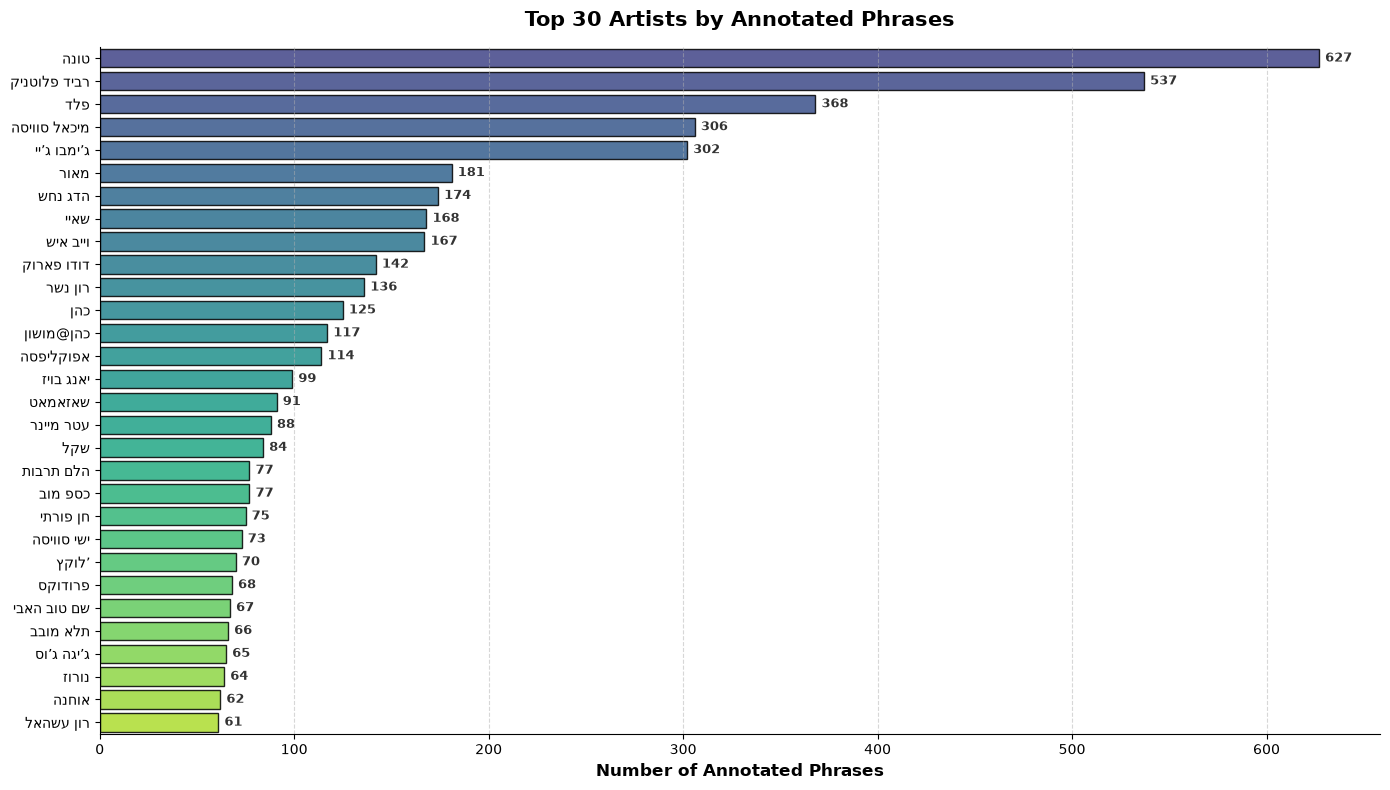

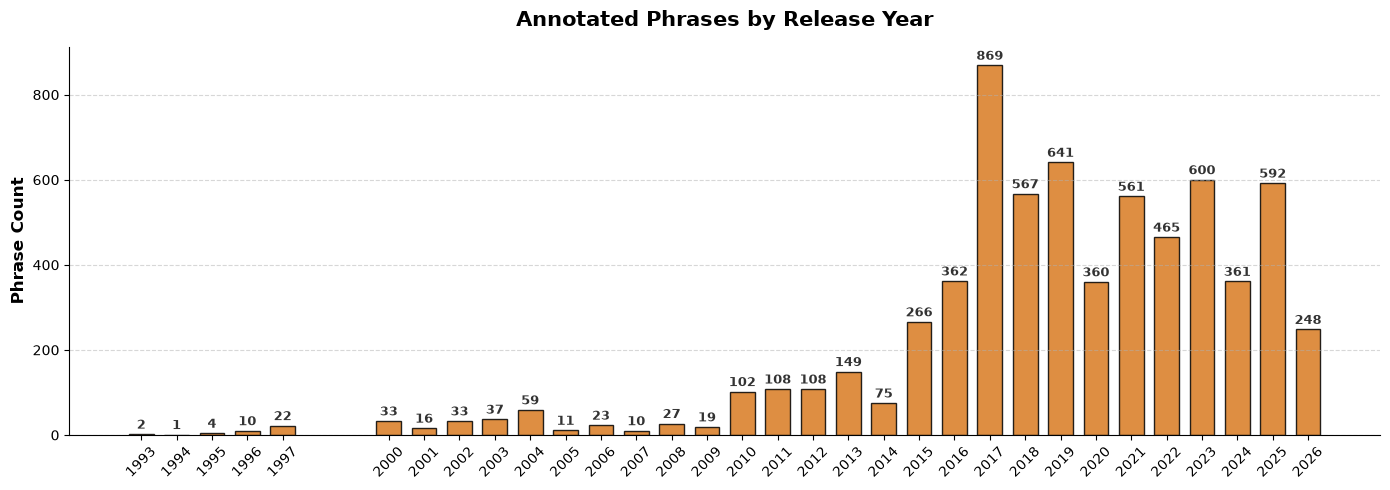

In [6]:
def plot_corpus_distributions(
    phrases_data: list[dict], 
    top_n_artists: int = 30
) -> None:
    """Plots phrase distributions across top artists and chronological release years."""
    df = pd.DataFrame(phrases_data)
    
    print(f"Total phrases: {len(df):,}")
    
    artist_col = "artist_clean" if "artist_clean" in df.columns else "artist_raw"
    print(f"Total distinct artists: {df[artist_col].nunique():,}")

    # Top Artists Chart
    artist_counts = df[artist_col].value_counts().head(top_n_artists)
    
    fig, ax = plt.subplots(figsize=(14, max(8, len(artist_counts) * 0.25)))
    
    colors = [
        plt.cm.viridis(0.2 + (i / len(artist_counts)) * 0.7)
        for i in range(len(artist_counts))
    ]
    
    bars = ax.barh(
        artist_counts.index, 
        artist_counts.values, 
        color=colors, 
        edgecolor="black", 
        alpha=0.85
    )
    
    ax.set_title(
        f"Top {top_n_artists} Artists by Annotated Phrases",
        fontsize=15,
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel("Number of Annotated Phrases", fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    
    ax.set_ylim(len(artist_counts) - 0.5, -0.5)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    offset = artist_counts.max() * 0.005
    for bar in bars:
        ax.text(
            bar.get_width() + offset, 
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", 
            va="center", 
            fontsize=9, 
            fontweight="bold",
            color="#333333"
        )
        
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
                
    plt.tight_layout()
    plt.show()

    print("\n" * 2)

    # Release Year Chart
    year_counts = (
        df["release_year"].dropna().astype(int).value_counts().sort_index()
    )
    
    fig2, ax2 = plt.subplots(figsize=(14, 5))
    bars2 = ax2.bar(
        year_counts.index, 
        year_counts.values, 
        color="#d97a21", 
        edgecolor="black", 
        alpha=0.85, 
        width=0.7
    )
    
    ax2.set_title(
        "Annotated Phrases by Release Year", 
        fontsize=15, 
        fontweight="bold", 
        pad=15
    )
    ax2.set_ylabel("Phrase Count", fontsize=12, fontweight="bold")
    
    ax2.set_xticks(year_counts.index)
    ax2.tick_params(axis="x", rotation=45)
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    
    y_offset = year_counts.max() * 0.015
    for bar in bars2:
        ax2.text(
            bar.get_x() + bar.get_width() / 2, 
            bar.get_height() + y_offset,
            f"{int(bar.get_height()):,}", 
            ha="center", 
            fontsize=9, 
            fontweight="bold",
            color="#333333"
        )
        
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
                 
    plt.tight_layout()
    plt.show()


plot_corpus_distributions(cleaned_dataset)

## Step 4: Initial filtering and autograding the phrases in the dataset

In [7]:
def filter_candidates(
    phrases: list[dict[str, Any]], 
    top_n: int = 300,
    max_per_artist: int = 8,
    seed: int = 42
) -> list[dict[str, Any]]:
    filtered = []
    
    for p in phrases:
        explanation = p.get("explanation", "").strip()
        fragment = p.get("fragment", "").strip()
        
        # 1. Structural filters
        if fragment.startswith("[") and fragment.endswith("]"):
            continue
            
        if not re.search(r"[\u0590-\u05FF]", fragment):  # Must contain Hebrew
            continue
            
        # 2. Strict community quality gates
        if not p.get("is_reviewed"):
            continue
            
        if p.get("votes", 0) < 1:
            continue
            
        # If it survives, it's a valid candidate
        filtered.append(p)

    # Completely shuffle the pool of valid candidates deterministically
    rng = random.Random(seed)
    rng.shuffle(filtered)
    
    # Enforce artist diversity limit
    top_candidates = []
    artist_counts = Counter()
    
    for candidate in filtered:
        artist = candidate.get("artist_clean", "")
        if artist_counts[artist] < max_per_artist:
            top_candidates.append(candidate)
            artist_counts[artist] += 1
            
        if len(top_candidates) == top_n:
            break
            
    print(f"Filtered {len(phrases):,} down to {len(filtered):,} valid candidates.")
    print(f"Kept {len(top_candidates)} in memory after applying artist limits.")
    
    return top_candidates


top_300 = filter_candidates(cleaned_dataset)

print("\n--- Top 10 Random Candidates (Passed Strict Filtering) ---")
for i, candidate in enumerate(top_300[:10], 1):
    print(f"{i}. {candidate['artist_clean']} - {candidate['title_clean']} "
          f"(Votes: {candidate['votes']}, Reviewed: {candidate['is_reviewed']})")
    print(f"   Fragment: {candidate['fragment']}")
    
    # Flatten newlines and truncate the explanation for a cleaner preview
    exp = candidate['explanation'].replace('\n', ' ')
    exp_preview = exp if len(exp) <= 120 else f"{exp[:117]}..."
    print(f"   Explanation: {exp_preview}\n")

Filtered 6,752 down to 1,651 valid candidates.
Kept 300 in memory after applying artist limits.

--- Top 10 Random Candidates (Passed Strict Filtering) ---
1. רביד פלוטניק - בור ועם הארץ (Votes: 1, Reviewed: True)
   Fragment: ”אָמַרְתִּי לָהּ - ”הַחַיִּים הֵם כְּמוֹ גַּלְגַּל
 ”הִיא עָנְתָה ”כַּפָּרָה כְּמוֹ שֶׁבְּשַׁבָּת
   Explanation: השוואת החיים לגלגל טוענת בעצם שהכל דינמי, מי שלמעלה יורד למטה ולהפך. במובן זה, גם שבשבת תספק את אותו האפקט, רק שבניגו...

2. עמית אולמן - אלוהים בג’ימייל (געגועים) (Votes: 2, Reviewed: True)
   Fragment: בין כל הדתות סלאש רשימות תפוצה
   Explanation: פדרו גראס ממשיך עם הדימוי האלוהי אל מול ג'ימייל ולכן כל דת היא בעצם מטאפורה לרשימת תפוצה, שמקבלת מכתבים מאותו השולח.

3. ג’ימבו ג’יי - רק אש (Votes: 2, Reviewed: True)
   Fragment: עד הסוף הייתה זרימה
 מפלי האיגוואסו
 לא היה כיור ולא היו סתימות
   Explanation: מפלי האיגוואסו שוכנים על גבול ברזיל-ארגנטינה-פרגוואי. מדובר במפלי ענק, שהוכרזו בשנת 2011 לאחד משבעת פלאי העולם החדשים...

4. אפוקליפסה - ערסופוב (V

## Step 5: Manually grading the 300 highest graded phrases & reducing the dataset size to 150

In [8]:
def clean_genius_annotation(text: str) -> str:
    """Strips URLs, image placeholders, and formatting junk from Genius annotations."""
    if not text:
        return ""
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"(?i)(תמונה של|להרחבה|לינק|שניה \d+).*", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def curate_benchmark_dataset(
    candidates: list[dict[str, Any]], 
    progress_path: Path,
    target_size: int = 150,
    seed: int = 42
) -> list[dict[str, Any]]:
    """
    Interactive curation loop forcing a categorical keep/discard reason.
    Automatically finalizes and shuffles once exactly target_size items are kept.
    """
    
    # 1. Define the rigorous inclusion/exclusion taxonomy
    keep_reasons = {
        "k1": "Lexical Ambiguity & Wordplay",
        "k2": "External Knowledge & Entity Resolution",
        "k3": "Localized Idiomatic Slang"
    }
    
    discard_reasons = {
        "d1": "Subjective / Unbounded Metaphor",
        "d2": "Internal Artist Catalog / Private Lore",
        "d3": "Low Semantic Friction (Trivial Baseline)",
        "d4": "Flawed / Inconclusive Annotation",
        "d5": "Low Linguistic Value / Tabloid Hyperbole"
    }
    
    valid_inputs = list(keep_reasons.keys()) + list(discard_reasons.keys()) + ['q']
    
    # 2. Load existing progress
    if progress_path.exists():
        with progress_path.open("r", encoding="utf-8") as f:
            graded_data = json.load(f)
        
        # Map existing progress back to the active candidates list
        graded_lookup = {
            f"{item['song_url']}_{item['fragment']}": {
                "status": item.get("curation_status"),
                "reason": item.get("curation_reason")
            }
            for item in graded_data if "curation_status" in item
        }
        
        for c in candidates:
            key = f"{c['song_url']}_{c['fragment']}"
            if key in graded_lookup:
                c["curation_status"] = graded_lookup[key]["status"]
                c["curation_reason"] = graded_lookup[key]["reason"]
    
    ungraded = [c for c in candidates if "curation_status" not in c]
    total_processed = len(candidates) - len(ungraded)
    kept_count = sum(1 for c in candidates if c.get("curation_status") == "keep")
    
    # 3. Interactive Curation Loop
    if ungraded and kept_count < target_size:
        recent_log = []
        
        for c in ungraded:
            # Stop condition: We hit exactly 150 kept items
            if kept_count >= target_size:
                print(f"\nTarget of {target_size} kept items reached! Stopping curation.")
                break
                
            clear_output(wait=True)
            
            if recent_log:
                print("--- Recent Decisions ---")
                for log_entry in recent_log[-4:]:
                    print(log_entry)
                print("\n")
                
            print(f"--- CURATION {total_processed + 1}/{len(candidates)} | KEPT: {kept_count}/{target_size} ---")
            print("[KEEP REASONS]")
            print(" k1: Lexical Ambiguity   | k2: External Knowledge | k3: Local Idiomatic Slang")
            print("\n[DISCARD REASONS]")
            print(" d1: Subjective Metaphor | d2: Internal Artist Lore | d3: Low Semantic Friction")
            print(" d4: Flawed Annotation   | d5: Tabloid Hyperbole    |  q: Save & Quit")
            print("-" * 75)
            
            while True:
                val = input("Enter reason (k1-k3, d1-d5, or 'q'): ").strip().lower()
                
                if val == 'q':
                    print("\nSaving progress and exiting...")
                    progress_path.parent.mkdir(parents=True, exist_ok=True)
                    with progress_path.open("w", encoding="utf-8") as f:
                        json.dump(candidates, f, ensure_ascii=False, indent=2)
                    
                    raise InterruptedError(
                        f"Curation paused. You have {kept_count}/{target_size} kept items. "
                        f"({len(candidates) - total_processed} items left to review)."
                    )
                    
                if val in valid_inputs:
                    if val.startswith('k'):
                        c["curation_status"] = "keep"
                        c["curation_reason"] = keep_reasons[val]
                        kept_count += 1
                        decision_str = f"✅ KEPT ({val})"
                    else:
                        c["curation_status"] = "discard"
                        c["curation_reason"] = discard_reasons[val]
                        decision_str = f"❌ DISCARDED ({val})"
                        
                    total_processed += 1
                    preview = c['fragment'].replace('\n', ' ')[:30]
                    recent_log.append(f"{decision_str}: {preview}...")
                    
                    # Atomic save
                    progress_path.parent.mkdir(parents=True, exist_ok=True)
                    with progress_path.open("w", encoding="utf-8") as f:
                        json.dump(candidates, f, ensure_ascii=False, indent=2)
                    break
                else:
                    print(f"Invalid input '{val}'. Please enter a valid code (k1-k3, d1-d5) or 'q'.")
                    
        clear_output(wait=True)
        if kept_count >= target_size:
            print(f"Target of {target_size} kept items reached successfully!\n")
        else:
            print("Finished reviewing all candidates, but did not reach target size.\n")

    # 4. Finalization
    print("Finalizing benchmark...")
    
    # Filter to only the kept items
    gold_benchmark = [c for c in candidates if c.get("curation_status") == "keep"]
    
    # 5. Clean formatting junk from explanations
    for item in gold_benchmark:
        item["explanation"] = clean_genius_annotation(item.get("explanation", ""))
    
    print(f"Successfully extracted, cleaned, and shuffled {len(gold_benchmark)} curated items!")
    print("Ready for multiple-choice distractor generation.")
    
    return gold_benchmark


# Execute the combined pipeline
gold_dataset_raw = curate_benchmark_dataset(top_300, PROGRESS_PATH, target_size=150)

Finalizing benchmark...
Successfully extracted, cleaned, and shuffled 123 curated items!
Ready for multiple-choice distractor generation.


## Step 6: Adding multiple choice options to the dataset phrases

In [9]:
# Initially we use Qwen 3.0 8B to generate questions locally
# For the final option creation we will use Gemini 3.1 Pro via Google API

TEST = False

if TEST:
    ACTIVE_MODEL = "qwen3:8b"
    api_key = "ollama" # Not used
    base_url = "http://localhost:11434/v1"
else:
    load_dotenv()
    ACTIVE_MODEL = "gemini-3.1-pro-preview"
    api_key = os.environ.get("GEMINI_API_KEY")
    base_url = "https://generativelanguage.googleapis.com/v1beta/openai/"

client = OpenAI(
    base_url=base_url,
    api_key=api_key,
    max_retries=0,    # Disable silent SDK retries so we can manage it explicitly
    timeout=120.0     # Drop the request if it takes longer than 120 seconds
)

STANDARDIZE_AND_DISTRACT_PROMPT = """
You are an elite expert in Israeli hip-hop culture, Hebrew slang, and rigorous NLP benchmark design.
I will provide a Hebrew rap lyric, its artist, and the crowdsourced explanation of its meaning.

Your task:
1. Summarize/rephrase the TRUE explanation into one clear, concise sentence (max 25 words) that sounds natural and professional.
2. Generate 3 plausible, highly convincing FALSE explanations (distractors) designed to genuinely trick an expert or an AI. 
   - Each distractor must represent a believable alternative theory that a casual listener or a superficial reader might mistake for the truth.
   - Avoid silly, absurd, or obviously fake options. Every distractor must sound like a legitimate piece of music journalism or cultural commentary.
   - All 4 options MUST have matching length, grammatical structure, and academic/professional tone so the correct answer cannot be guessed by structural elimination.

Respond ONLY with a valid JSON object in this exact schema:
{
  "true_explanation": "ההסבר הנכון והמתומצת",
  "distractors": [
    "הסבר שגוי ראשון משכנע",
    "הסבר שגוי שני משכנע",
    "הסבר שגוי שלישי משכנע"
  ]
}
"""

def generate_gold_benchmark(
    gold_candidates: list[dict[str, Any]], 
    output_path: Path,
    llm_client: OpenAI,
    model_name: str,
    seed: int = 42
) -> list[dict[str, Any]]:
    """Generates standardized answers and distractors, shuffling into fixed A/B/C/D format."""
    
    benchmark: list[dict[str, Any]] = []
    
    if output_path.exists():
        with output_path.open("r", encoding="utf-8") as f:
            benchmark = json.load(f)
            
    completed_keys = {f"{item['song_url']}_{item['fragment']}" for item in benchmark}
    pending = [
        c for c in gold_candidates 
        if f"{c['song_url']}_{c['fragment']}" not in completed_keys
    ]
    
    if not pending:
        print("All benchmark items already generated and frozen!")
        return benchmark

    # Local RNG ensures reproducible shuffling independent of global state
    rng = random.Random(seed)
    labels = ["A", "B", "C", "D"]

    print(f"Generating benchmark items for {len(pending)} phrases using {model_name}...")
    
    for item in tqdm(pending, desc="Building Benchmark"):
        user_message = (
            f"Artist: {item['artist_clean']}\n"
            f"Song: {item['title_clean']}\n"
            f"Context:\n{item.get('context_stanza', '')}\n\n"
            f"Fragment: {item['fragment']}\n"
            f"Crowdsourced Explanation: {item['explanation']}"
        )
        
        # Automatic retry logic for transient 503 / 429 server spikes
        max_retries = 5
        retry_delay = 15
        success = False
        data = None

        for attempt in range(max_retries):
            try:
                response = llm_client.chat.completions.create(
                    model=model_name,
                    messages=[
                        {"role": "system", "content": STANDARDIZE_AND_DISTRACT_PROMPT},
                        {"role": "user", "content": user_message}
                    ],
                    response_format={"type": "json_object"},
                    temperature=0.7
                )
                
                raw_content = response.choices[0].message.content.strip()
                if raw_content.startswith("```json"):
                    raw_content = raw_content[7:-3].strip()
                elif raw_content.startswith("```"):
                    raw_content = raw_content[3:-3].strip()
                    
                data = json.loads(raw_content)
                success = True
                break
                
            except Exception as e:
                err_str = str(e)
                # Catch temporary overloads (503), rate limits (429), or timeouts
                if "503" in err_str or "429" in err_str or "timed out" in err_str.lower():
                    if attempt < max_retries - 1:
                        print(f"\nServer hiccup on '{item['fragment']}': {err_str}")
                        print(f"Retrying in {retry_delay} seconds (Attempt {attempt + 1}/{max_retries})...")
                        time.sleep(retry_delay)
                        retry_delay *= 2 # Exponential backoff
                        continue
                # If it's a permanent error or retries ran out, raise it to trigger checkpoint break
                raise e

        if not success or not data:
            print(f"\nFailed permanently on item '{item['fragment']}'")
            break

        true_exp = data.get("true_explanation", "").strip()
        distractors = data.get("distractors", [])
        
        if not true_exp or len(distractors) != 3:
            print(f"\nFailed on item '{item['fragment']}': Model output did not match expected schema.")
            break
            
        # Combine and shuffle options
        all_choices = [
            {"text": true_exp, "is_correct": True},
            {"text": distractors[0], "is_correct": False},
            {"text": distractors[1], "is_correct": False},
            {"text": distractors[2], "is_correct": False},
        ]
        rng.shuffle(all_choices)
        
        # Map shuffled options to fixed letters A, B, C, D
        options_dict = {}
        correct_label = None
        for label, choice in zip(labels, all_choices):
            options_dict[label] = choice["text"]
            if choice["is_correct"]:
                correct_label = label
                
        benchmark_record = {
            "id": f"heb_rap_{len(benchmark) + 1:03d}",
            "song_url": item["song_url"],
            "artist": item["artist_clean"],
            "song_title": item["title_clean"],
            "fragment": item["fragment"],
            "context_stanza": item.get("context_stanza", ""),
            "options": options_dict,
            "correct_label": correct_label,
            "raw_genius_explanation": item["explanation"],
            "auto_score": item.get("auto_score"),
            "manual_score": item.get("manual_score")
        }
        
        benchmark.append(benchmark_record)
        
        # Atomic checkpoint save
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with output_path.open("w", encoding="utf-8") as f:
            json.dump(benchmark, f, ensure_ascii=False, indent=2)
            
        # Rate limit safety pause
        time.sleep(6)

    print(f"\nBenchmark ready: {len(benchmark)} frozen multiple-choice questions saved to: {output_path}")
    return benchmark


test_benchmark = generate_gold_benchmark(
    gold_candidates=gold_dataset_raw,
    output_path=GOLD_BENCHMARK_PATH,
    llm_client=client,
    model_name=ACTIVE_MODEL
)

Generating benchmark items for 123 phrases using gemini-3.1-pro-preview...


Building Benchmark:   0%|          | 0/123 [00:00<?, ?it/s]


Benchmark ready: 123 frozen multiple-choice questions saved to: ..\data\processed\gold_benchmark_150.json


## Step 7: Close manual inspection of the final dataset

In [10]:
# Print the first 3 items
for item in test_benchmark[:20]:
    print(json.dumps(item, indent=2, ensure_ascii=False))
    print("," + "\n")

{
  "id": "heb_rap_001",
  "song_url": "https://genius.com/Apocalipsa-arsofob-lyrics",
  "artist": "אפוקליפסה",
  "song_title": "ערסופוב",
  "fragment": "כל אחד תופס סכין פרפר כדי להרגיש חופשי",
  "context_stanza": "[וורס 2: אודימן]\nאז מאה בשבילי? לא מאה בשבילך וואלה\nהאזור פה מסריח כמו ראשי התיבות של פרדס חנה\nלחיות את הדרמה אתה לא לומד?\nהשיכור הזקן ששכח כבר איך לחיות עוד לא מת\nכולם פה עם סגריה על האוזן יום שישי\nערסים מתקרבים לדת ילדים מעשנים חשיש\nכל אחד תופס סכין פרפר כדי להרגיש חופשי\nשכונה בירידה כמו פנס של מלשין\nסוחר קשוח מוריד אנשים על גרם יש לו שם\nואם הרגיש שדפקו אותו גם אלוקים יהיה אשם\nמשקפיי שמש שחורים עם\nכלב פיטבול לבן\nעוד נרקומן מזריק לוריד ממזרק התרופה של הבן שלו הקטן\nסמטאות מלאות בבקבוקי וודקה ריקים\nחופשי חודשי לבית קברות וואלה מתאים\nהשכונה מתייבשת בגלל בנאדם שלא בא בטוב למקום\nוכל אחד יורה כמו הגשם הראשון",
  "options": {
    "A": "מטאפורה לעולם הסמים וסחר ברחוב: הסכין משמשת לחיתוך סמים, ותחושת החופש מתארת את האסקפיזם והבריחה מהמציאות הקשה באמצעות שימוש בחומר

## Bonus chart: most popular words in Hebrew rap songs 

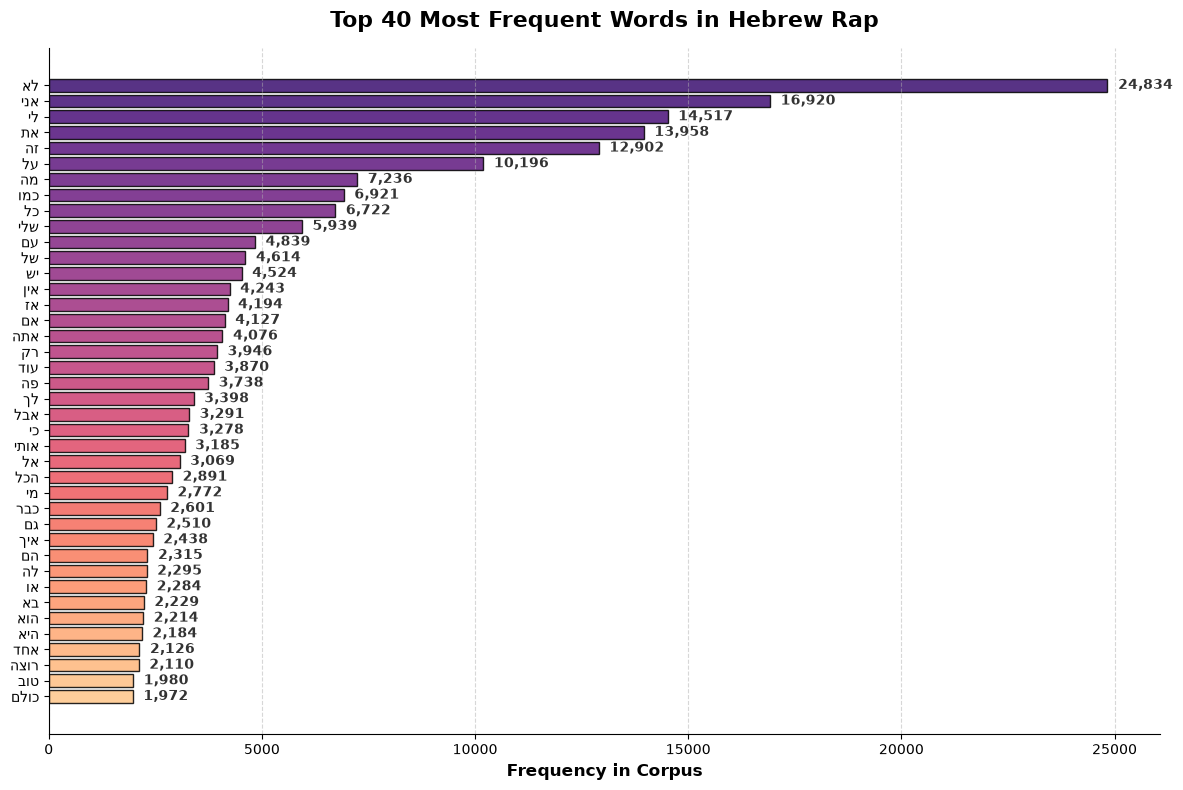

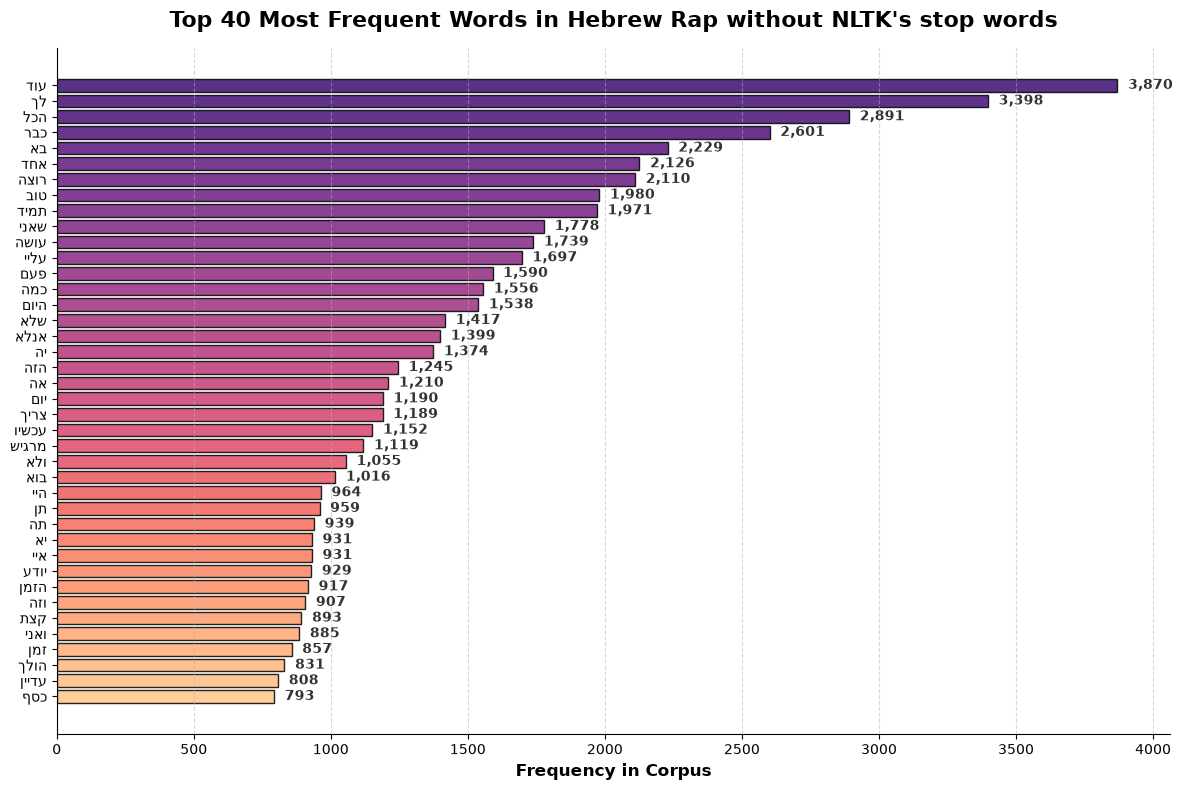

In [11]:
def plot_top_rap_words(
    corpus: dict[str, dict[str, Any]],
    top_n: int = 40,
    stop_words: set[str] = set(),
    title: str = "",
) -> None:
    """Plots a Matplotlib bar chart of the most frequent words in the lyrics."""
    # Ignore 'tag' noise
    stop_words = stop_words.union({"פזמון", "בית", "וורס", "אינטרו", "אאוטרו", "מעבר"})
    
    all_words = []
    
    for song in corpus.values():
        if lyrics := song.get("lyrics", ""):
            # 1. Erase apostrophes, quotes, and geresh entirely (אנ'לא -> אנלא)
            clean_lyrics = re.sub(r"['׳\"״]", "", lyrics)
            
            # 2. Extract only contiguous Hebrew letters
            words = re.findall(r"[\u0590-\u05FF]+", clean_lyrics)
            
            all_words.extend([w for w in words if len(w) > 1 and w not in stop_words])

    top_words = Counter(all_words).most_common(40)
    df = pd.DataFrame(top_words, columns=["Word", "Count"])

    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = [plt.cm.magma(0.2 + (i / len(df)) * 0.7) for i in range(len(df))]
    
    bars = ax.barh(
        df["Word"], 
        df["Count"], 
        color=colors, 
        edgecolor="black",
        alpha=0.85
    )
    title = f"Top {top_n} Most Frequent Words in Hebrew Rap" if not title else title
    ax.set_title(
        title, 
        fontsize=16, 
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel("Frequency in Corpus", fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    
    offset = df["Count"].max() * 0.01
    for bar in bars:
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}",
            va="center", 
            fontsize=10, 
            fontweight="bold",
            color="#333333"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# Plot most frequent words
plot_top_rap_words(corpus)

# Plot most frequent words again, filtering out NLTK's built in Hebrew stop words
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("hebrew"))
top_n = 40
title = f"Top {top_n} Most Frequent Words in Hebrew Rap without NLTK's stop words"
plot_top_rap_words(corpus, top_n, stop_words, title)

**Very funny to see how frequent are the words "לא" (no) and "אני" (me),<br>
as well as the 'rap sounds' of "אה" (ah), "יה" (yeah), "היי" (hey)**